In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

print(os.listdir("/content/drive/MyDrive/DL_Case_Study"))

['AAPL-LSTM-Stock-Prediction']


In [7]:
import os

project_path = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

print("Project contents:")
print(os.listdir(project_path))

Project contents:
['models', 'data']


In [8]:
models_path = os.path.join(project_path, "models")

print("Model folder contents:")
print(os.listdir(models_path))

Model folder contents:
['AAPL_LSTM_Final.keras', 'AAPL_MinMaxScaler.pkl']


In [9]:
# ============================================================
# LOAD TRAINED LSTM MODEL AND SCALER
# ============================================================

from tensorflow.keras.models import load_model
import joblib
import os

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"
MODEL_PATH = os.path.join(PROJECT_PATH, "models", "AAPL_LSTM_Final.keras")
SCALER_PATH = os.path.join(PROJECT_PATH, "models", "AAPL_MinMaxScaler.pkl")

# Load trained LSTM
model = load_model(MODEL_PATH)

# Load training scaler
scaler = joblib.load(SCALER_PATH)

print("========================================")
print(" MODEL AND SCALER LOADED SUCCESSFULLY")
print("========================================")
print("Model file :", MODEL_PATH)
print("Scaler file:", SCALER_PATH)
print("========================================")

 MODEL AND SCALER LOADED SUCCESSFULLY
Model file : /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_LSTM_Final.keras
Scaler file: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_MinMaxScaler.pkl


In [10]:
# ============================================================
# UPLOAD NEW STOCK DATA FOR PREDICTION
# ============================================================

from google.colab import files
import pandas as pd

print("Please upload your new AAPL stock CSV file.")

uploaded = files.upload()

prediction_filename = list(uploaded.keys())[0]

new_df = pd.read_csv(prediction_filename)

print("\n========================================")
print("       INPUT DATA LOADED")
print("========================================")
print("File:", prediction_filename)
print("Rows:", len(new_df))
print("Columns:", new_df.columns.tolist())

display(new_df.head())

Please upload your new AAPL stock CSV file.


KeyboardInterrupt: 

In [11]:
import os

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

print("Project folder exists:", os.path.exists(PROJECT_PATH))

print("\nContents of project folder:")
print(os.listdir(PROJECT_PATH))

print("\nContents of data folder:")
DATA_FOLDER = os.path.join(PROJECT_PATH, "data")
print(os.listdir(DATA_FOLDER))

Project folder exists: True

Contents of project folder:
['models', 'data']

Contents of data folder:
['Apple (AAPL) From 1980 To Dec-2024.csv']


In [13]:
# ============================================================
# CREATE 60-DAY PREDICTION INPUT CSV
# ============================================================

import pandas as pd
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "Apple (AAPL) From 1980 To Dec-2024.csv"
)

# ------------------------------------------------------------
# Load original AAPL dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Original dataset shape:", df.shape)

# ------------------------------------------------------------
# Process Date
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    utc=True
)

df["Date"] = df["Date"].dt.tz_localize(None)

df = df.dropna(subset=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# ------------------------------------------------------------
# Use the same period as the trained model
# ------------------------------------------------------------

df = df[
    (df["Date"] >= "2015-01-01") &
    (df["Date"] <= "2024-12-31")
].copy()

df = df.sort_values("Date").reset_index(drop=True)

# ------------------------------------------------------------
# Required features
# ------------------------------------------------------------

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

# Check that all required columns exist
missing_columns = [
    col for col in features
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in dataset: {missing_columns}"
    )

# ------------------------------------------------------------
# Take the latest 60 trading days
# ------------------------------------------------------------

prediction_df = df[
    ["Date"] + features
].tail(60).copy()

# ------------------------------------------------------------
# Save prediction CSV
# ------------------------------------------------------------

PREDICTION_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "AAPL_Prediction_Input_60_Days.csv"
)

prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n========================================")
print("  PREDICTION INPUT CSV CREATED")
print("========================================")
print("File:", PREDICTION_PATH)
print("Number of records:", len(prediction_df))
print("Start date:", prediction_df["Date"].iloc[0].date())
print("End date:", prediction_df["Date"].iloc[-1].date())
print("========================================")

display(prediction_df)

Dataset loaded successfully!
Original dataset shape: (11084, 6)

  PREDICTION INPUT CSV CREATED
File: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/data/AAPL_Prediction_Input_60_Days.csv
Number of records: 60
Start date: 2024-09-06
End date: 2024-11-29


,Date,Open,High,Low,Close,Volume
2435,2024-09-06 04:00:00,223.703881,224.992472,219.528482,220.577332,48423000
2436,2024-09-09 04:00:00,220.577324,221.026826,216.471840,220.667221,67180000
2437,2024-09-10 04:00:00,218.679408,221.236593,216.491813,219.868103,51591000
2438,2024-09-11 04:00:00,221.216620,222.844819,217.650536,222.415299,44587100
2439,2024-09-12 04:00:00,222.255470,223.304319,219.578422,222.525177,37498200
2440,2024-09-13 04:00:00,223.334293,223.793779,221.666130,222.255478,36766600
2441,2024-09-16 04:00:00,216.302020,216.981280,213.684904,216.082275,59357400
2442,2024-09-17 04:00:00,215.512892,216.661622,214.264266,216.551743,45519300
2443,2024-09-18 04:00:00,217.310915,222.465248,217.300917,220.447464,59894900
2444,2024-09-19 04:00:00,224.742744,229.567437,224.383139,228.618469,66781300


In [14]:
# ============================================================
# LOAD TRAINED LSTM MODEL AND SCALER
# ============================================================

from tensorflow.keras.models import load_model
import joblib
import os

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "AAPL_LSTM_Final.keras"
)

SCALER_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "AAPL_MinMaxScaler.pkl"
)

# Load trained model
model = load_model(MODEL_PATH)

# Load scaler used during training
scaler = joblib.load(SCALER_PATH)

print("========================================")
print("MODEL AND SCALER LOADED")
print("========================================")
print("Model:", MODEL_PATH)
print("Scaler:", SCALER_PATH)
print("========================================")

MODEL AND SCALER LOADED
Model: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_LSTM_Final.keras
Scaler: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_MinMaxScaler.pkl


In [15]:
# ============================================================
# AAPL NEXT-DAY PREDICTION FROM CSV
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# Load prediction input CSV
# ------------------------------------------------------------

PREDICTION_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "AAPL_Prediction_Input_60_Days.csv"
)

prediction_df = pd.read_csv(PREDICTION_PATH)

# ------------------------------------------------------------
# Validate columns
# ------------------------------------------------------------

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

required_columns = ["Date"] + features

missing_columns = [
    col for col in required_columns
    if col not in prediction_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Process dates
# ------------------------------------------------------------

prediction_df["Date"] = pd.to_datetime(
    prediction_df["Date"],
    errors="coerce",
    utc=True
)

prediction_df["Date"] = prediction_df["Date"].dt.tz_localize(None)

prediction_df = prediction_df.dropna(
    subset=["Date"]
)

prediction_df = prediction_df.sort_values(
    "Date"
).reset_index(drop=True)

# ------------------------------------------------------------
# Check number of records
# ------------------------------------------------------------

if len(prediction_df) < 60:
    raise ValueError(
        f"At least 60 records are required. "
        f"Only {len(prediction_df)} records found."
    )

# Take exactly the latest 60 trading days
latest_60 = prediction_df.tail(60).copy()

# ------------------------------------------------------------
# Prepare data for LSTM
# ------------------------------------------------------------

latest_data = latest_60[features].values

# Apply the SAME scaler used during training
latest_scaled = scaler.transform(latest_data)

# LSTM expects:
# (batch_size, sequence_length, number_of_features)

X_input = latest_scaled.reshape(
    1,
    60,
    len(features)
)

print("Input shape:", X_input.shape)

# ------------------------------------------------------------
# Predict next-day Close
# ------------------------------------------------------------

predicted_scaled = model.predict(
    X_input,
    verbose=0
)

# ------------------------------------------------------------
# Convert prediction back to original price
# ------------------------------------------------------------

dummy_prediction = np.zeros(
    (1, len(features))
)

# Close is the 4th feature → index 3
dummy_prediction[0, 3] = predicted_scaled[0, 0]

predicted_close = scaler.inverse_transform(
    dummy_prediction
)[0, 3]

# ------------------------------------------------------------
# Get latest actual values
# ------------------------------------------------------------

last_date = latest_60["Date"].iloc[-1]
last_close = latest_60["Close"].iloc[-1]

price_change = predicted_close - last_close

percentage_change = (
    price_change / last_close
) * 100

# ------------------------------------------------------------
# Display prediction
# ------------------------------------------------------------

print("\n============================================")
print("       AAPL NEXT-TRADING-DAY PREDICTION")
print("============================================")
print(f"Input records          : {len(latest_60)}")
print(f"Last available date    : {last_date.date()}")
print(f"Last actual close      : ${last_close:.2f}")
print("--------------------------------------------")
print(f"Predicted next close   : ${predicted_close:.2f}")
print(f"Expected price change  : ${price_change:.2f}")
print(f"Expected change        : {percentage_change:.2f}%")
print("============================================")

Input shape: (1, 60, 5)

       AAPL NEXT-TRADING-DAY PREDICTION
Input records          : 60
Last available date    : 2024-11-29
Last actual close      : $237.33
--------------------------------------------
Predicted next close   : $231.40
Expected price change  : $-5.93
Expected change        : -2.50%


In [16]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("File uploaded successfully!")
print("Filename:", filename)

Saving AAPL_New_Prediction_Input_60_Days.csv to AAPL_New_Prediction_Input_60_Days.csv
File uploaded successfully!
Filename: AAPL_New_Prediction_Input_60_Days.csv


In [17]:
import pandas as pd

input_df = pd.read_csv(filename)

print("============================================")
print("       PREDICTION CSV VALIDATION")
print("============================================")

print("Shape:", input_df.shape)

print("\nColumns:")
print(input_df.columns.tolist())

print("\nFirst 5 records:")
display(input_df.head())

print("\nLast 5 records:")
display(input_df.tail())

print("\nMissing values:")
print(input_df.isnull().sum())

       PREDICTION CSV VALIDATION
Shape: (60, 6)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

First 5 records:


,Date,Open,High,Low,Close,Volume
0,2024-09-06,223.703881,224.992472,219.528482,220.577332,48423000
1,2024-09-09,220.577324,221.026826,216.471840,220.667221,67180000
2,2024-09-10,218.679408,221.236593,216.491813,219.868103,51591000
3,2024-09-11,221.216620,222.844819,217.650536,222.415299,44587100
4,2024-09-12,222.255470,223.304319,219.578422,222.525177,37498200



Last 5 records:


,Date,Open,High,Low,Close,Volume
55,2024-11-22,228.059998,230.720001,228.059998,229.869995,38168300
56,2024-11-25,231.460007,233.250000,229.740005,232.869995,90152800
57,2024-11-26,233.330002,235.570007,233.330002,235.059998,45986200
58,2024-11-27,234.470001,235.690002,233.809998,234.929993,33498400
59,2024-11-29,234.809998,237.809998,233.970001,237.330002,28481400



Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [18]:
input_df["Date"] = pd.to_datetime(input_df["Date"])

print("============================================")
print("           DATE VALIDATION")
print("============================================")

print("First date :", input_df["Date"].iloc[0])
print("Last date  :", input_df["Date"].iloc[-1])

print("\nDates in chronological order:",
      input_df["Date"].is_monotonic_increasing)

print("Duplicate dates:", input_df["Date"].duplicated().sum())

print("\nNumber of records:", len(input_df))

           DATE VALIDATION
First date : 2024-09-06 00:00:00
Last date  : 2024-11-29 00:00:00

Dates in chronological order: True
Duplicate dates: 0

Number of records: 60


In [19]:
import os
import joblib
from tensorflow.keras.models import load_model

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "AAPL_LSTM_Final.keras"
)

SCALER_PATH = os.path.join(
    PROJECT_PATH,
    "models",
    "AAPL_MinMaxScaler.pkl"
)

model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("============================================")
print("       MODEL AND SCALER LOADED")
print("============================================")
print("Model :", MODEL_PATH)
print("Scaler:", SCALER_PATH)

       MODEL AND SCALER LOADED
Model : /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_LSTM_Final.keras
Scaler: /content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction/models/AAPL_MinMaxScaler.pkl


In [20]:
import numpy as np

features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Select the 5 features expected by the LSTM
input_data = input_df[features].values

print("Original input shape:", input_data.shape)

# Apply the SAME scaler used during training
input_scaled = scaler.transform(input_data)

# Reshape for LSTM
X_new = input_scaled.reshape(1, 60, 5)

print("============================================")
print("       LSTM INPUT PREPARED")
print("============================================")
print("Input shape:", X_new.shape)

Original input shape: (60, 5)
       LSTM INPUT PREPARED
Input shape: (1, 60, 5)


In [21]:
# Make prediction
prediction_scaled = model.predict(X_new, verbose=0)

print("Scaled prediction:", prediction_scaled[0][0])

Scaled prediction: 1.3303831


In [22]:
# Convert scaled prediction back to actual AAPL price

dummy_prediction = np.zeros((1, 5))

# Close is the 4th feature (index 3)
dummy_prediction[0, 3] = prediction_scaled[0, 0]

# Inverse transform
predicted_price = scaler.inverse_transform(dummy_prediction)[0, 3]

print("============================================")
print("       NEXT-DAY AAPL PREDICTION")
print("============================================")
print(f"Last available date : {input_df['Date'].iloc[-1].date()}")
print(f"Last actual close   : ${input_df['Close'].iloc[-1]:.2f}")
print(f"Predicted next close: ${predicted_price:.2f}")

       NEXT-DAY AAPL PREDICTION
Last available date : 2024-11-29
Last actual close   : $237.33
Predicted next close: $231.40


In [23]:
# Calculate prediction change
last_close = input_df['Close'].iloc[-1]

price_change = predicted_price - last_close
percentage_change = (price_change / last_close) * 100

print("====================================================")
print("          AAPL LSTM STOCK PRICE PREDICTION")
print("====================================================")
print(f"Input data period    : {input_df['Date'].iloc[0].date()} to {input_df['Date'].iloc[-1].date()}")
print(f"Trading days used    : {len(input_df)}")
print("----------------------------------------------------")
print(f"Last closing price   : ${last_close:.2f}")
print(f"Predicted next close : ${predicted_price:.2f}")
print(f"Expected change      : ${price_change:.2f}")
print(f"Expected change (%)  : {percentage_change:.2f}%")
print("----------------------------------------------------")

if predicted_price > last_close:
    print("Prediction direction  : 📈 UP")
elif predicted_price < last_close:
    print("Prediction direction  : 📉 DOWN")
else:
    print("Prediction direction  : ➡️ STABLE")

print("====================================================")

          AAPL LSTM STOCK PRICE PREDICTION
Input data period    : 2024-09-06 to 2024-11-29
Trading days used    : 60
----------------------------------------------------
Last closing price   : $237.33
Predicted next close : $231.40
Expected change      : $-5.93
Expected change (%)  : -2.50%
----------------------------------------------------
Prediction direction  : 📉 DOWN


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

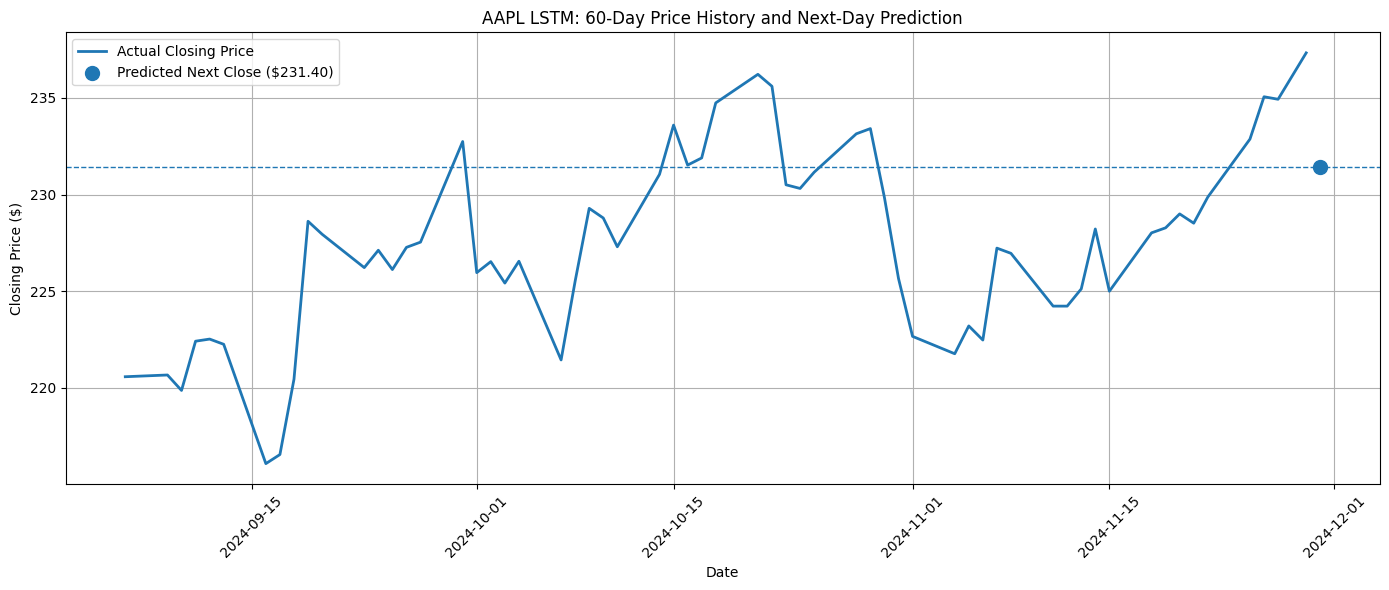

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

dates = input_df['Date']

plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    input_df['Close'],
    label='Actual Closing Price',
    linewidth=2
)

# Use the next calendar day only for visualization
next_date = dates.iloc[-1] + pd.Timedelta(days=1)

plt.scatter(
    next_date,
    predicted_price,
    label=f'Predicted Next Close (${predicted_price:.2f})',
    s=100
)

plt.axhline(
    predicted_price,
    linestyle='--',
    linewidth=1
)

plt.title('AAPL LSTM: 60-Day Price History and Next-Day Prediction')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# LOAD FINAL SAVED MODEL AND SCALER
# ============================================================

from tensorflow.keras.models import load_model
import joblib
import os

PROJECT_PATH = "/content/drive/MyDrive/DL_Case_Study/AAPL-LSTM-Stock-Prediction"

MODEL_PATH = os.path.join(
    PROJECT_PATH, "models", "AAPL_LSTM_Final.keras"
)

SCALER_PATH = os.path.join(
    PROJECT_PATH, "models", "AAPL_MinMaxScaler.pkl"
)

model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("==========================================")
print("       FINAL MODEL LOADED")
print("==========================================")
print("Model loaded successfully!")
print("Scaler loaded successfully!")
print("==========================================")

       FINAL MODEL LOADED
Model loaded successfully!
Scaler loaded successfully!


In [29]:
# ============================================================
# FINAL SAVED MODEL — NEXT-DAY PREDICTION
# ============================================================

features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Use the 60-day input data already loaded in input_df
input_data = input_df[features].values

# Scale using the SAVED training scaler
input_scaled = scaler.transform(input_data)

# Reshape for LSTM
X_new = input_scaled.reshape(1, 60, 5)

# Predict
prediction_scaled = model.predict(X_new, verbose=0)

# Convert predicted Close back to original price scale
dummy_prediction = np.zeros((1, 5))
dummy_prediction[0, 3] = prediction_scaled[0, 0]

predicted_price = scaler.inverse_transform(
    dummy_prediction
)[0, 3]

# Last actual price
last_close = input_df['Close'].iloc[-1]
last_date = input_df['Date'].iloc[-1]

# Change
price_change = predicted_price - last_close
percentage_change = (price_change / last_close) * 100

print("==========================================")
print("     FINAL AAPL LSTM PREDICTION")
print("==========================================")
print(f"Input period         : {input_df['Date'].iloc[0].date()} to {last_date.date()}")
print(f"Trading days         : {len(input_df)}")
print(f"Last actual close    : ${last_close:.2f}")
print(f"Predicted next close : ${predicted_price:.2f}")
print(f"Expected change      : ${price_change:.2f}")
print(f"Expected change %    : {percentage_change:.2f}%")
print(f"Direction             : {'UP' if price_change > 0 else 'DOWN'}")
print("==========================================")

     FINAL AAPL LSTM PREDICTION
Input period         : 2024-09-06 to 2024-11-29
Trading days         : 60
Last actual close    : $237.33
Predicted next close : $225.29
Expected change      : $-12.04
Expected change %    : -5.07%
Direction             : DOWN
